In [2]:
!pip install mp-api -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.6/41.6 MB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 40.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 44.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.1/126.1 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 62.9 MB/s eta 0:00:00
   ━━━━━━━━━

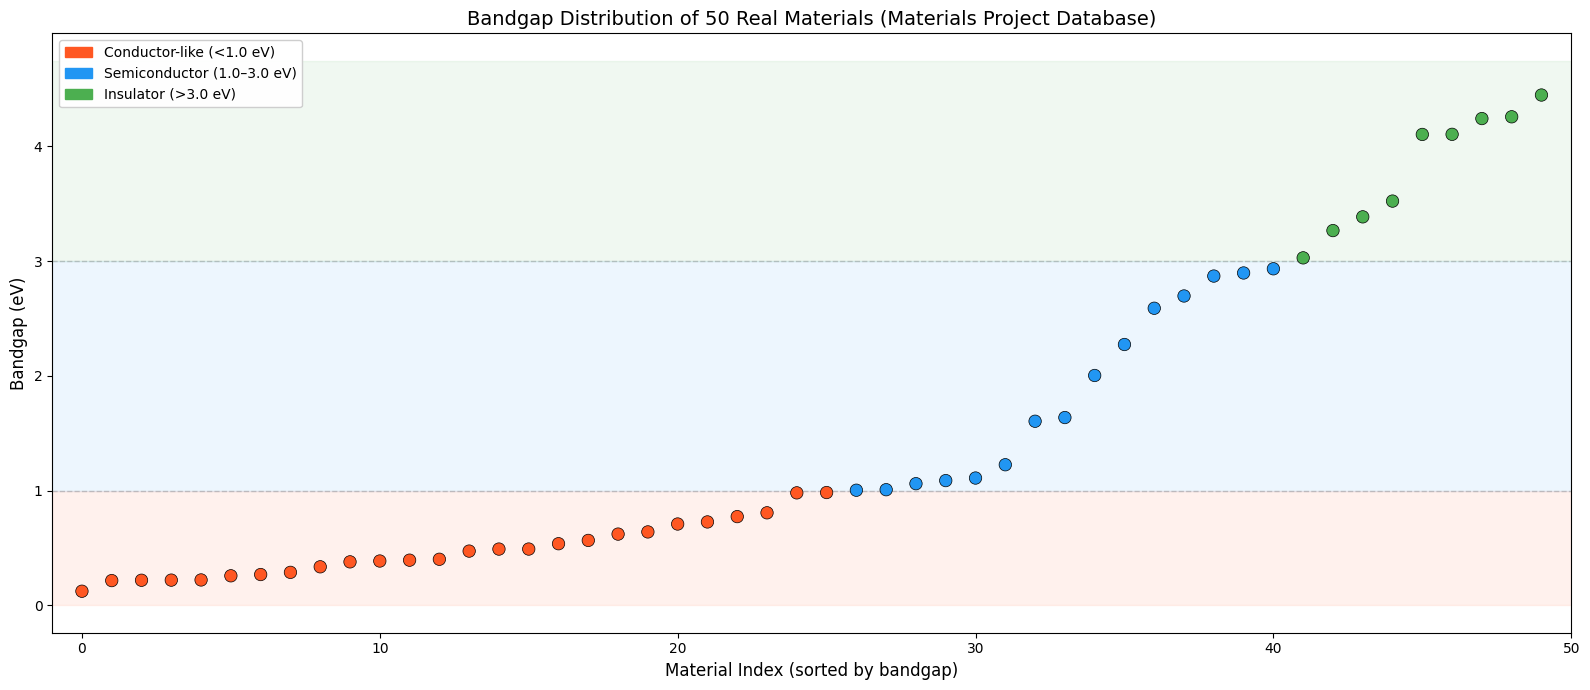

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

category_colors = {
    "Conductor-like": "#FF5722",
    "Semiconductor": "#2196F3",
    "Insulator": "#4CAF50"
}

df_sorted = df_real.sort_values("Bandgap_eV").reset_index(drop=True)
colors = [category_colors[c] for c in df_sorted["Category"]]

plt.figure(figsize=(16, 7))

# Shaded background zones instead of side text
plt.axhspan(0, 1.0, color="#FF5722", alpha=0.08, zorder=0)
plt.axhspan(1.0, 3.0, color="#2196F3", alpha=0.08, zorder=0)
plt.axhspan(3.0, df_sorted["Bandgap_eV"].max() + 0.3, color="#4CAF50", alpha=0.08, zorder=0)

plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.4, linewidth=1)
plt.axhline(y=3.0, color='gray', linestyle='--', alpha=0.4, linewidth=1)

plt.scatter(range(len(df_sorted)), df_sorted["Bandgap_eV"],
            c=colors, s=80, edgecolors='black', linewidth=0.5, zorder=3)

patches = [mpatches.Patch(color=c, label=f"{k} ({'<1.0' if k=='Conductor-like' else '1.0–3.0' if k=='Semiconductor' else '>3.0'} eV)")
           for k, c in category_colors.items()]
plt.legend(handles=patches, loc='upper left', fontsize=10, framealpha=0.95)

plt.title(f"Bandgap Distribution of {len(df_sorted)} Real Materials (Materials Project Database)", fontsize=14)
plt.xlabel("Material Index (sorted by bandgap)", fontsize=12)
plt.ylabel("Bandgap (eV)", fontsize=12)
plt.xlim(-1, len(df_sorted))
plt.tight_layout()
plt.savefig("real_materials_distribution.png", dpi=150)
plt.show()

from google.colab import files
files.download("real_materials_distribution.png")

In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = df_real2[["Bandgap_eV"]]
y = df_real2["Is_Metal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_metal2 = DecisionTreeClassifier(max_depth=3)
model_metal2.fit(X_train, y_train)

predictions = model_metal2.predict(X_test)
accuracy = accuracy_score(y_test, predictions)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"Accuracy: {accuracy * 100:.1f}%")
print()
print(classification_report(y_test, predictions, zero_division=0))

Training samples: 64
Testing samples: 16
Accuracy: 100.0%

              precision    recall  f1-score   support

       False       1.00      1.00      1.00         1
        True       1.00      1.00      1.00        15

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16

